In [18]:
# CELL 1: MOUNT GOOGLE DRIVE + INSTALL DEPENDENCIES
# =============================================================================
# ┌─────────────────────────────────────────────────────────────┐
# │  PASTE THE FOLLOWING 4 LINES INTO YOUR FIRST COLAB CELL:   │
# │                                                             │
# │  from google.colab import drive                             │
# │  drive.mount('/content/drive')                              │
# │  !pip install -q --upgrade mne                              │
# │  !pip install -q fooof scipy scikit-learn                   │

from google.colab import drive
drive.mount('/content/drive')
!pip install -q --upgrade mne
!pip install -q fooof scipy scikit-learn

import numpy as np
import scipy.signal as signal
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
import mne
from fooof import FOOOFGroup
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
import scipy.io
import os
import gc
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"MNE: {mne.__version__}")

# --- Verify Google Drive is mounted ---
drive_path = '/content/drive/MyDrive/BCI_IV_2b'
if os.path.exists(drive_path):
    files_found = [f for f in os.listdir(drive_path) if f.endswith('.gdf')]
    print(f"\n✅ Google Drive mounted! Found {len(files_found)} .gdf files in BCI_IV_2b/")
    if len(files_found) < 45:
        print(f"   ⚠️  Expected 45 files (9 subjects × 5 sessions). You have {len(files_found)}.")
else:
    print(f"\n❌ Folder not found: {drive_path}")
    print("   Please create a folder 'BCI_IV_2b' in your Google Drive root")
    print("   and upload all 45 .gdf files there.")

print("\nSetup complete!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.19.0
MNE: 1.12.0

✅ Google Drive mounted! Found 45 .gdf files in BCI_IV_2b/

Setup complete!


In [3]:
# %% =========================================================================
# CELL 2: CONFIGURATION
# =============================================================================
# --- Paths (Google Drive) ---
DATA_DIR = '/content/drive/MyDrive/BCI_IV_2b'  # Your Google Drive folder

# --- Signal Parameters ---
FS = 250.0                        # Sampling rate (Hz)
TMIN = 0.5                        # Epoch start relative to cue (seconds)
TMAX_EXCLUSIVE = 4.5              # Epoch end (exclusive, gives 1000 samples)
N_CHANNELS = 3                    # C3, Cz, C4
N_TIMEPOINTS = 1000               # 4 seconds * 250 Hz

# --- Frequency Bands ---
BANDS = {
    'delta': (1.0, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0),
}

# --- Training Hyperparameters (from the paper) ---
LEARNING_RATE = 0.001
MOMENTUM = 0.9
N_EPOCHS = 300
BATCH_SIZE = 16
DROPOUT_RATE = 0.5
L2_LAMBDA = 0.01                  # Keras L2 value (effective weight decay ~0.02)
FC_UNITS = 256                    # Fully connected layer hidden units

# --- Subject Configuration ---
N_SUBJECTS = 9
SUBJECTS = list(range(1, N_SUBJECTS + 1))

print("Configuration loaded.")
print(f"  Data directory: {DATA_DIR}")
print(f"  Subjects: {SUBJECTS}")
print(f"  Training: SGD(lr={LEARNING_RATE}, momentum={MOMENTUM}), {N_EPOCHS} epochs")

Configuration loaded.
  Data directory: /content/drive/MyDrive/BCI_IV_2b
  Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  Training: SGD(lr=0.001, momentum=0.9), 300 epochs


In [20]:
# CELL 3: DATA LOADING FUNCTIONS
# =============================================================================
def load_single_gdf(file_path, label_file_path=None):
    """
    Load a single .gdf file and extract MI epochs + labels.

    For TRAINING files (T): labels come from events 769/770 in the GDF.
    For EVALUATION files (E): trials are marked by event 783 ("cue unknown")
        and true labels must be loaded from a separate .mat file.

    Returns X (n_trials, n_channels, n_timepoints), y (n_trials,)
    """
    if not os.path.exists(file_path):
        print(f"  [WARNING] File not found: {file_path}")
        return None, None

    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose='ERROR')

    # --- Keep only EEG channels (drop EOG and others) ---
    eeg_picks = []
    target_ch = ['C3', 'Cz', 'C4']
    for ch in raw.ch_names:
        if any(t in ch for t in target_ch):
            eeg_picks.append(ch)

    if len(eeg_picks) == 0:
        # Fallback: pick by type
        raw.pick_types(eeg=True, eog=False, misc=False)
    else:
        raw.pick_channels(eeg_picks)

    # --- Apply Bandpass Filter (0.5 - 100 Hz) ---
    raw.filter(l_freq=0.5, h_freq=100.0, fir_design='firwin', verbose='ERROR')

    # --- Apply Notch Filter (50 Hz power line) ---
    raw.notch_filter(freqs=50.0, verbose='ERROR')

    # --- Extract Events ---
    events, event_dict = mne.events_from_annotations(raw, verbose='ERROR')

    # ---- Try to find events 769 (left MI) / 770 (right MI) ----
    left_id = event_dict.get('769')
    right_id = event_dict.get('770')

    if left_id is None or right_id is None:
        # Try numeric keys (some MNE/GDF versions wrap in np.str_)
        for key, val in event_dict.items():
            if '769' in str(key):
                left_id = val
            if '770' in str(key):
                right_id = val

    # ================================================================
    # PATH A: Training file — labels are embedded as events 769 / 770
    # ================================================================
    if left_id is not None and right_id is not None:
        custom_event_id = {'Left_MI': left_id, 'Right_MI': right_id}

        tmax = TMAX_EXCLUSIVE - (1 / FS)  # Ensure exactly 1000 samples
        epochs = mne.Epochs(
            raw, events, custom_event_id,
            tmin=TMIN, tmax=tmax,
            baseline=None, preload=True, verbose='ERROR'
        )

        X = epochs.get_data()  # (n_trials, n_channels, n_timepoints)
        y = epochs.events[:, -1]
        y = np.where(y == left_id, 0, 1)  # Binary: 0=Left, 1=Right
        return X, y

    # ================================================================
    # PATH B: Evaluation file — use event 783 + external .mat labels
    # ================================================================
    # Find event 783 ("cue unknown" — marks trial onset in eval files)
    cue_id = None
    for key, val in event_dict.items():
        if '783' in str(key):
            cue_id = val
            break

    if cue_id is None:
        print(f"  [WARNING] Neither events 769/770 nor 783 found in {file_path}")
        print(f"            Available events: {event_dict}")
        return None, None

    # Check that the label file exists
    if label_file_path is None or not os.path.exists(label_file_path):
        print(f"  [WARNING] Label file required but not found: {label_file_path}")
        print(f"            Evaluation (E) files need matching .mat true-label files.")
        print(f"            Download them from: https://www.bbci.de/competition/iv/results/")
        print(f"            (Look for 'True Labels of Competition Evaluation Sets')")
        return None, None

    # Epoch using event 783
    custom_event_id = {'MI_Cue': cue_id}
    tmax = TMAX_EXCLUSIVE - (1 / FS)
    epochs = mne.Epochs(
        raw, events, custom_event_id,
        tmin=TMIN, tmax=tmax,
        baseline=None, preload=True, verbose='ERROR'
    )

    X = epochs.get_data()  # (n_trials, n_channels, n_timepoints)

    # Load true labels from the .mat file
    mat_data = scipy.io.loadmat(label_file_path)

    # Find the label array — common variable names in BCI IV 2b
    labels = None
    for key in ['classlabel', 'true_labels', 'labels', 'y', 'true_y']:
        if key in mat_data:
            labels = mat_data[key].flatten()
            break

    if labels is None:
        # Fallback: find any array whose length could match trial count
        for key, val in mat_data.items():
            if key.startswith('_'):
                continue
            if isinstance(val, np.ndarray) and val.ndim <= 2:
                flat = val.flatten()
                if len(flat) >= X.shape[0]:
                    labels = flat
                    print(f"  [INFO] Using variable '{key}' from {os.path.basename(label_file_path)} as labels")
                    break

    if labels is None:
        mat_keys = [k for k in mat_data.keys() if not k.startswith('_')]
        print(f"  [WARNING] Could not find labels in {label_file_path}")
        print(f"            Available variables: {mat_keys}")
        return None, None

    # Handle dropped epochs: align labels to surviving epochs
    if len(labels) != X.shape[0]:
        if hasattr(epochs, 'selection') and epochs.selection is not None:
            kept = epochs.selection
            if len(kept) == X.shape[0] and np.max(kept) < len(labels):
                labels = labels[kept]
                print(f"  [INFO] Aligned labels via epoch selection ({len(kept)} kept)")

    if len(labels) != X.shape[0]:
        print(f"  [WARNING] Label count ({len(labels)}) != epoch count ({X.shape[0]})")
        # Truncate to the smaller count as last resort
        n = min(len(labels), X.shape[0])
        labels = labels[:n]
        X = X[:n]

    # BCI IV 2b convention: 1 = left hand, 2 = right hand → 0 / 1
    y = (labels - 1).astype(int)

    return X, y


def load_subject_data(subject_id, data_dir):
    """
    Load ALL 5 sessions for a subject.
    Returns: X_train, y_train (3 sessions), X_test, y_test (2 sessions)

    Training sessions (T): labels from GDF events 769/770.
    Evaluation sessions (E): labels from .mat files in the same directory.
    """
    sid = f'{subject_id:02d}'
    print(f"\n{'='*60}")
    print(f"Loading Subject {subject_id} (B{sid})")
    print(f"{'='*60}")

    # Training files: sessions 1-3 (no external labels needed)
    train_files = [
        os.path.join(data_dir, f'B{sid}01T.gdf'),
        os.path.join(data_dir, f'B{sid}02T.gdf'),
        os.path.join(data_dir, f'B{sid}03T.gdf'),
    ]

    # Evaluation files: sessions 4-5 + matching .mat label files
    test_files = [
        (
            os.path.join(data_dir, f'B{sid}04E.gdf'),
            os.path.join(data_dir, f'B{sid}04E.mat'),
        ),
        (
            os.path.join(data_dir, f'B{sid}05E.gdf'),
            os.path.join(data_dir, f'B{sid}05E.mat'),
        ),
    ]

    X_train_parts, y_train_parts = [], []
    for f in train_files:
        fname = os.path.basename(f)
        X, y = load_single_gdf(f)  # T files: labels from GDF events
        if X is not None:
            X_train_parts.append(X)
            y_train_parts.append(y)
            print(f"  [TRAIN] {fname}: {X.shape[0]} trials loaded")

    X_test_parts, y_test_parts = [], []
    for gdf_file, mat_file in test_files:
        fname = os.path.basename(gdf_file)
        X, y = load_single_gdf(gdf_file, label_file_path=mat_file)  # E files
        if X is not None:
            X_test_parts.append(X)
            y_test_parts.append(y)
            print(f"  [TEST]  {fname}: {X.shape[0]} trials loaded")

    if len(X_train_parts) == 0 or len(X_test_parts) == 0:
        print(f"  [ERROR] Insufficient data for subject {subject_id}")
        return None, None, None, None

    X_train = np.concatenate(X_train_parts, axis=0)
    y_train = np.concatenate(y_train_parts, axis=0)
    X_test = np.concatenate(X_test_parts, axis=0)
    y_test = np.concatenate(y_test_parts, axis=0)

    print(f"  Total Training: {X_train.shape} | Labels: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"  Total Testing:  {X_test.shape}  | Labels: {dict(zip(*np.unique(y_test, return_counts=True)))}")

    return X_train, y_train, X_test, y_test


print("Data loading functions ready.")

Data loading functions ready.


In [5]:
# %% =========================================================================
# CELL 4: FILTER BANK (FREQUENCY BAND DECOMPOSITION)
# =============================================================================
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Create Butterworth bandpass filter coefficients."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a


def apply_filter_bank(X, fs=FS):
    """
    Decompose EEG data into canonical frequency bands.
    Input:  X of shape (trials, channels, timepoints)
    Output: dict of filtered data per band, same shape
    """
    filtered_data = {}
    for band_name, (low, high) in BANDS.items():
        b, a = butter_bandpass(low, high, fs)
        X_filtered = signal.filtfilt(b, a, X, axis=-1)
        filtered_data[band_name] = X_filtered
    return filtered_data


print("Filter bank functions ready.")

Filter bank functions ready.


In [6]:
# %% =========================================================================
# CELL 5: INTRINSIC FEATURE EXTRACTION (DE + NPS)
# =============================================================================
def extract_de_features(X_bands):
    """
    Differential Entropy (DE) for each channel and frequency band.
    DE = 0.5 * log(2 * pi * e * variance)
    Output shape: (n_trials, n_channels * n_bands) = (trials, 12)
    """
    bands_order = ['delta', 'theta', 'alpha', 'beta']
    trials, channels, _ = X_bands['delta'].shape

    de_matrix = np.zeros((trials, channels, len(bands_order)))
    for b_idx, band in enumerate(bands_order):
        variance = np.var(X_bands[band], axis=-1)
        de = 0.5 * np.log(2 * np.pi * np.e * (variance + 1e-9))
        de_matrix[:, :, b_idx] = de

    return de_matrix.reshape(trials, -1)  # (trials, 12)


def extract_nps_features(X, fs=FS):
    """
    Neural Power Spectra (NPS) aperiodic features using FOOOF.
    Extracts offset and exponent of 1/f background per channel.
    Output shape: (n_trials, n_channels * 2) = (trials, 6)
    """
    trials, channels, _ = X.shape

    # Compute Welch PSD
    freqs, spectra = signal.welch(X, fs=fs, nperseg=int(fs * 2))
    spectra_reshaped = spectra.reshape(-1, spectra.shape[-1])  # (trials*channels, freqs)

    # Fit FOOOF
    fg = FOOOFGroup(
        peak_width_limits=[1.0, 8.0],
        max_n_peaks=4,
        min_peak_height=0.1,
        verbose=False
    )
    fg.fit(freqs, spectra_reshaped, [1.0, 30.0])

    aperiodic_params = fg.get_params('aperiodic_params')  # (trials*channels, 2)

    # Handle NaN from failed fits
    if np.any(np.isnan(aperiodic_params)):
        col_means = np.nanmean(aperiodic_params, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        for j in range(aperiodic_params.shape[1]):
            nan_mask = np.isnan(aperiodic_params[:, j])
            aperiodic_params[nan_mask, j] = col_means[j]

    nps_features = aperiodic_params.reshape(trials, -1)  # (trials, 6)
    return nps_features


def extract_all_intrinsic_features(X, X_bands):
    """Combine DE and NPS into a single intrinsic feature vector."""
    de = extract_de_features(X_bands)       # (trials, 12)
    nps = extract_nps_features(X)           # (trials, 6)
    intrinsic = np.concatenate([de, nps], axis=1)  # (trials, 18)
    return intrinsic


print("Feature extraction functions ready.")

Feature extraction functions ready.


In [7]:
# %% =========================================================================
# CELL 6: DATA AUGMENTATION (4 Methods from the Paper)
# =============================================================================
def add_gaussian_noise(X, noise_level=0.01):
    """Add Gaussian noise to EEG signals."""
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise


def segment_and_recombine(X, y, num_segments=4):
    """
    Segment-and-recombine augmentation.
    Splits each trial into segments and recombines with segments
    from other trials of the SAME class.
    """
    trials, channels, timepoints = X.shape
    segment_length = timepoints // num_segments
    X_new = np.zeros_like(X)

    for class_label in np.unique(y):
        class_indices = np.where(y == class_label)[0]
        for target_idx in class_indices:
            recombined = np.zeros((channels, timepoints))
            for seg in range(num_segments):
                donor_idx = np.random.choice(class_indices)
                start = seg * segment_length
                end = start + segment_length
                recombined[:, start:end] = X[donor_idx, :, start:end]
            X_new[target_idx] = recombined

    return X_new


def window_slicing(X, slice_ratio=0.9):
    """
    Window slicing: take a random sub-window and resample to original length.
    """
    trials, channels, timepoints = X.shape
    slice_length = int(timepoints * slice_ratio)
    X_new = np.zeros_like(X)

    for i in range(trials):
        start_idx = np.random.randint(0, timepoints - slice_length)
        end_idx = start_idx + slice_length
        sliced = X[i, :, start_idx:end_idx]
        for c in range(channels):
            X_new[i, c, :] = np.interp(
                np.linspace(0, 1, timepoints),
                np.linspace(0, 1, slice_length),
                sliced[c, :]
            )
    return X_new


def window_warping(X, warp_ratio=0.1, warp_speed=2.0):
    """
    Window warping: speed up or slow down a random window of the signal.
    """
    trials, channels, timepoints = X.shape
    window_length = int(timepoints * warp_ratio)
    X_new = np.zeros_like(X)

    for i in range(trials):
        speed_factor = warp_speed if np.random.rand() > 0.5 else 1.0 / warp_speed
        warped_length = max(int(window_length / speed_factor), 2)
        start_idx = np.random.randint(0, timepoints - window_length)
        end_idx = start_idx + window_length

        for c in range(channels):
            window_data = X[i, c, start_idx:end_idx]
            warped_window = np.interp(
                np.linspace(0, 1, warped_length),
                np.linspace(0, 1, window_length),
                window_data
            )
            combined = np.concatenate([
                X[i, c, :start_idx],
                warped_window,
                X[i, c, end_idx:]
            ])
            X_new[i, c, :] = np.interp(
                np.linspace(0, 1, timepoints),
                np.linspace(0, 1, len(combined)),
                combined
            )
    return X_new


def augment_training_data(X, y):
    """
    Apply all 4 augmentation methods. Returns 5x the original data.
    """
    print("  Applying data augmentation (5x expansion)...")
    X_gn = add_gaussian_noise(X)
    X_sr = segment_and_recombine(X, y)
    X_ws = window_slicing(X)
    X_ww = window_warping(X)

    X_aug = np.concatenate([X, X_gn, X_sr, X_ws, X_ww], axis=0)
    y_aug = np.concatenate([y, y, y, y, y], axis=0)

    print(f"  Augmented: {X.shape[0]} → {X_aug.shape[0]} trials")
    return X_aug, y_aug


print("Data augmentation functions ready.")

Data augmentation functions ready.


In [8]:
# %% =========================================================================
# CELL 7: MS-CNN MODEL ARCHITECTURE
# =============================================================================
def create_mscb(input_tensor, block_name):
    """
    Multi-Scale Convolutional Block (MSCB) — Level 1.5

    4 parallel branches with different kernel sizes:
      - Branch L (Large):  Conv(14, 1×5) → MaxPool(1×5)
      - Branch M (Medium): Conv(14, 1×3) → MaxPool(1×3)
      - Branch S (Small):  Conv(14, 1×1) → MaxPool(1×1)
      - Branch P (Pool-first): MaxPool(1×3) → Conv(24, 1×3)

    All branches use stride (1,5) for compatible concatenation.

    Output stage: Conv(112, 1×3) → MaxPool(1×5) → Conv(112, 1×3) [level 1.5]
    """
    pool_stride = (1, 5)

    # Branch 1: Large kernel
    b1 = layers.Conv2D(14, (1, 5), padding='same', activation='relu',
                       name=f'{block_name}_L_conv')(input_tensor)
    b1 = layers.MaxPooling2D((1, 5), strides=pool_stride, padding='same',
                             name=f'{block_name}_L_pool')(b1)

    # Branch 2: Medium kernel
    b2 = layers.Conv2D(14, (1, 3), padding='same', activation='relu',
                       name=f'{block_name}_M_conv')(input_tensor)
    b2 = layers.MaxPooling2D((1, 3), strides=pool_stride, padding='same',
                             name=f'{block_name}_M_pool')(b2)

    # Branch 3: Small kernel
    b3 = layers.Conv2D(14, (1, 1), padding='same', activation='relu',
                       name=f'{block_name}_S_conv')(input_tensor)
    b3 = layers.MaxPooling2D((1, 1), strides=pool_stride, padding='same',
                             name=f'{block_name}_S_pool')(b3)

    # Branch 4: Pool-first (auxiliary)
    b4 = layers.MaxPooling2D((1, 3), strides=pool_stride, padding='same',
                             name=f'{block_name}_P_pool')(input_tensor)
    b4 = layers.Conv2D(24, (1, 3), padding='same', activation='relu',
                       name=f'{block_name}_P_conv')(b4)

    # Concatenate all branches
    concat = layers.Concatenate(axis=-1,
                                name=f'{block_name}_concat')([b1, b2, b3, b4])

    # Output stage — Level 1: Conv + Pool
    x = layers.Conv2D(112, (1, 3), strides=(1, 1), padding='same',
                      activation='relu',
                      name=f'{block_name}_out_conv')(concat)
    x = layers.MaxPooling2D((1, 5), strides=(1, 5), padding='same',
                            name=f'{block_name}_out_pool')(x)

    # Level 1.5: Additional Conv (optimal configuration per paper)
    x = layers.Conv2D(112, (1, 3), strides=(1, 1), padding='same',
                      activation='relu',
                      name=f'{block_name}_extra_conv')(x)

    return layers.Flatten(name=f'{block_name}_flatten')(x)


def build_ms_cnn(n_channels=N_CHANNELS, n_timepoints=N_TIMEPOINTS,
                 n_intrinsic=18):
    """
    Build the complete MS-CNN model.

    Architecture:
      4 MSCB blocks (one per frequency band: δ, θ, α, β)
      + Intrinsic features (DE + NPS)
      → Feature Fusion (concatenation)
      → BatchNorm
      → Dense(FC_UNITS, relu, L2)
      → Dropout(0.5)
      → Dense(2, softmax)
    """
    input_shape = (n_channels, n_timepoints, 1)

    # 4 band inputs
    in_delta = Input(shape=input_shape, name='input_delta')
    in_theta = Input(shape=input_shape, name='input_theta')
    in_alpha = Input(shape=input_shape, name='input_alpha')
    in_beta  = Input(shape=input_shape, name='input_beta')

    # Intrinsic feature input
    in_intrinsic = Input(shape=(n_intrinsic,), name='input_intrinsic')

    # Process each band through its own MSCB
    feat_delta = create_mscb(in_delta, 'MSCB_Delta')
    feat_theta = create_mscb(in_theta, 'MSCB_Theta')
    feat_alpha = create_mscb(in_alpha, 'MSCB_Alpha')
    feat_beta  = create_mscb(in_beta,  'MSCB_Beta')

    # Feature Fusion: concatenate all MSCB outputs + intrinsic features
    fused = layers.Concatenate(name='Feature_Fusion')([
        feat_delta, feat_theta, feat_alpha, feat_beta, in_intrinsic
    ])

    # Classification head
    x = layers.BatchNormalization(name='BN_Fusion')(fused)
    x = layers.Dense(FC_UNITS, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_LAMBDA),
                     kernel_initializer='glorot_uniform',  # Xavier init
                     name='FC_Layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='Dropout')(x)
    output = layers.Dense(2, activation='softmax', name='Output')(x)

    model = models.Model(
        inputs=[in_delta, in_theta, in_alpha, in_beta, in_intrinsic],
        outputs=output,
        name='MS_CNN'
    )

    return model


# Quick test
test_model = build_ms_cnn()
test_model.summary()
del test_model
tf.keras.backend.clear_session()
gc.collect()
print("\nModel architecture verified!")

Model: "MS_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_delta         │ (None, 3, 1000,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_theta         │ (None, 3, 1000,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_alpha         │ (None, 3, 1000,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_beta          │ (None, 3, 1000,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Delta_L_conv   │ (None, 3, 1000,   │         84 │ input_delta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Delta_M_conv   │ (None, 3, 1000,   │         56 │ input_delta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Delta_S_conv   │ (None, 3, 1000,   │         28 │ input_delta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Delta_P_pool   │ (None, 3, 200, 1) │          0 │ input_delta[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Theta_L_conv   │ (None, 3, 1000,   │         84 │ input_theta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Theta_M_conv   │ (None, 3, 1000,   │         56 │ input_theta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Theta_S_conv   │ (None, 3, 1000,   │         28 │ input_theta[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Theta_P_pool   │ (None, 3, 200, 1) │          0 │ input_theta[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Alpha_L_conv   │ (None, 3, 1000,   │         84 │ input_alpha[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Alpha_M_conv   │ (None, 3, 1000,   │         56 │ input_alpha[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Alpha_S_conv   │ (None, 3, 1000,   │         28 │ input_alpha[0][0] │
│ (Conv2D)            │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Alpha_P_pool   │ (None, 3, 200, 1) │          0 │ input_alpha[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MSCB_Beta_L_conv    │ (None, 3, 1000,   │         84 │ input_beta[0][0]

 Total params: 14,224,234 (54.26 MB)

 Trainable params: 14,116,678 (53.85 MB)

 Non-trainable params: 107,556 (420.14 KB)


Model architecture verified!


In [9]:
# %% =========================================================================
# CELL 8: DATA PREPARATION UTILITIES
# =============================================================================
def prepare_model_inputs(X_bands, intrinsic_features):
    """
    Format data as list of inputs for the multi-input Keras model.
    Each band tensor: (trials, channels, timepoints, 1)
    """
    inputs = []
    for band_name in ['delta', 'theta', 'alpha', 'beta']:
        band_data = np.expand_dims(X_bands[band_name], axis=-1)
        inputs.append(band_data.astype(np.float32))
    inputs.append(intrinsic_features.astype(np.float32))
    return inputs


def normalize_inputs(train_inputs, test_inputs):
    """
    Z-score normalize each input using TRAINING statistics only.
    This prevents data leakage from test to train.
    """
    norm_train = []
    norm_test = []

    for i in range(len(train_inputs)):
        if train_inputs[i].ndim == 2:
            # Intrinsic features: normalize per feature (column)
            mean = np.mean(train_inputs[i], axis=0, keepdims=True)
            std = np.std(train_inputs[i], axis=0, keepdims=True) + 1e-8
        else:
            # Band tensors: normalize globally
            mean = np.mean(train_inputs[i])
            std = np.std(train_inputs[i]) + 1e-8

        norm_train.append(((train_inputs[i] - mean) / std).astype(np.float32))
        norm_test.append(((test_inputs[i] - mean) / std).astype(np.float32))

    return norm_train, norm_test


print("Data preparation utilities ready.")

Data preparation utilities ready.


In [10]:
# %% =========================================================================
# CELL 9: LEARNING RATE SCHEDULE
# =============================================================================
def lr_schedule(epoch):
    """
    Step decay: drop learning rate by 0.5 every 100 epochs.
    Paper: "The initial learning rate is set to 0.001 and the learning rate
           drops every 100 epochs by 0.5 multiplicatively."
    """
    return LEARNING_RATE * (0.5 ** (epoch // 100))


print("LR schedule ready:")
for e in [0, 99, 100, 199, 200, 299]:
    print(f"  Epoch {e}: lr = {lr_schedule(e):.6f}")

LR schedule ready:
  Epoch 0: lr = 0.001000
  Epoch 99: lr = 0.001000
  Epoch 100: lr = 0.000500
  Epoch 199: lr = 0.000500
  Epoch 200: lr = 0.000250
  Epoch 299: lr = 0.000250


In [11]:
# %% =========================================================================
# CELL 10: TRAINING AND EVALUATION PIPELINE (MAIN LOOP)
# =============================================================================
def train_and_evaluate_subject(subject_id, data_dir=DATA_DIR):
    """
    Complete pipeline for a single subject:
    1. Load data (3 train sessions + 2 test sessions)
    2. Filter bank decomposition
    3. Feature extraction (DE + NPS)
    4. Augmentation (training only)
    5. Build and train model
    6. Evaluate on test sessions
    """
    start_time = time.time()

    # ---- Step 1: Load Data ----
    X_train_raw, y_train, X_test_raw, y_test = load_subject_data(subject_id, data_dir)
    if X_train_raw is None:
        return None

    # ---- Step 2: Filter Bank ----
    print("  Applying filter bank...")
    train_bands = apply_filter_bank(X_train_raw)
    test_bands = apply_filter_bank(X_test_raw)

    # ---- Step 3: NPS Features (on original data only — FOOOF is expensive) ----
    print("  Extracting NPS features (original data)...")
    nps_train_orig = extract_nps_features(X_train_raw)
    nps_test = extract_nps_features(X_test_raw)

    # ---- Step 4: Augment Training Data ----
    X_train_aug, y_train_aug = augment_training_data(X_train_raw, y_train)

    # Filter bank on augmented data
    print("  Applying filter bank to augmented data...")
    train_bands_aug = apply_filter_bank(X_train_aug)

    # DE features on augmented data (fast)
    print("  Extracting DE features (augmented data)...")
    de_train_aug = extract_de_features(train_bands_aug)

    # NPS: replicate original NPS for each augmented copy (5x)
    n_orig = X_train_raw.shape[0]
    nps_train_aug = np.tile(nps_train_orig, (5, 1))  # 5x copies

    # Combine intrinsic features
    intrinsic_train = np.concatenate([de_train_aug, nps_train_aug], axis=1)

    # Test intrinsic features
    de_test = extract_de_features(test_bands)
    intrinsic_test = np.concatenate([de_test, nps_test], axis=1)

    print(f"  Intrinsic features — Train: {intrinsic_train.shape}, Test: {intrinsic_test.shape}")

    # ---- Step 5: Prepare Model Inputs ----
    train_inputs = prepare_model_inputs(train_bands_aug, intrinsic_train)
    test_inputs = prepare_model_inputs(test_bands, intrinsic_test)

    # Normalize using training statistics
    train_inputs, test_inputs = normalize_inputs(train_inputs, test_inputs)

    y_train_final = y_train_aug.astype(np.float32)
    y_test_final = y_test.astype(np.float32)

    # Free memory
    del X_train_raw, X_test_raw, X_train_aug
    del train_bands, test_bands, train_bands_aug
    del de_train_aug, nps_train_orig, nps_train_aug, nps_test, de_test
    gc.collect()

    # ---- Step 6: Shuffle Training Data ----
    indices = np.arange(len(y_train_final))
    np.random.shuffle(indices)
    train_inputs = [x[indices] for x in train_inputs]
    y_train_final = y_train_final[indices]

    # ---- Step 7: Build Fresh Model ----
    tf.keras.backend.clear_session()
    model = build_ms_cnn(n_intrinsic=intrinsic_train.shape[1])

    # Compile with SGD + momentum (paper specification)
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    )
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0)

    # ---- Step 8: Train ----
    print(f"\n  Training for {N_EPOCHS} epochs...")
    history = model.fit(
        x=train_inputs,
        y=y_train_final,
        batch_size=BATCH_SIZE,
        epochs=N_EPOCHS,
        validation_split=0.1,  # 10% for monitoring only
        callbacks=[lr_callback],
        verbose=1
    )

    # ---- Step 9: Evaluate on Test Sessions ----
    print("\n  Evaluating on held-out test sessions (E files)...")
    test_loss, test_acc = model.evaluate(test_inputs, y_test_final, verbose=0)

    y_pred_proba = model.predict(test_inputs, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = y_test_final.astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    kappa = cohen_kappa_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    elapsed = time.time() - start_time

    print(f"\n  ┌─────────────────────────────────────┐")
    print(f"  │ Subject {subject_id} Results                  │")
    print(f"  ├─────────────────────────────────────┤")
    print(f"  │ Test Accuracy:  {acc:6.2f}%              │")
    print(f"  │ Cohen's Kappa:  {kappa:6.4f}              │")
    print(f"  │ F1 Score:       {f1:6.4f}              │")
    print(f"  │ Time:           {elapsed/60:5.1f} min            │")
    print(f"  └─────────────────────────────────────┘")

    # Clean up
    result = {
        'accuracy': acc,
        'kappa': kappa,
        'f1': f1,
        'history': history.history,
        'time': elapsed,
    }

    del model, train_inputs, test_inputs
    tf.keras.backend.clear_session()
    gc.collect()

    return result


print("Training pipeline ready!")

Training pipeline ready!


In [21]:
# %% =========================================================================
# CELL 11: RUN ALL 9 SUBJECTS
# =============================================================================
print("\n" + "█" * 60)
print("█  MS-CNN: Running ALL 9 Subjects")
print("█  Paper Target: 93.74% average accuracy")
print("█" * 60)

all_results = {}

for subject_id in SUBJECTS:
    result = train_and_evaluate_subject(subject_id, DATA_DIR)
    if result is not None:
        all_results[subject_id] = result

Streaming output truncated to the last 5000 lines.
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7028 - loss: 1.7791 - val_accuracy: 0.5150 - val_loss: 2.0643 - learning_rate: 0.0010
Epoch 33/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7050 - loss: 1.7253 - val_accuracy: 0.5000 - val_loss: 2.0145 - learning_rate: 0.0010
Epoch 34/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7000 - loss: 1.6725 - val_accuracy: 0.4900 - val_loss: 1.9612 - learning_rate: 0.0010
Epoch 35/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7011 - loss: 1.6171 - val_accuracy: 0.4850 - val_loss: 1.9033 - learning_rate: 0.0010
Epoch 36/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6983 - loss: 1.5739 - val_accuracy: 0.4900 - val_loss: 1.8425 - learning_rate: 0.0010
Epoch 37/300
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6961 - loss: 1.5248 - val_accuracy: 0.5200 - val_loss: 1.8254 - learning_rate: 0.0010
Epoch 38/300
113/113 ━━━━━━━━━━━


════════════════════════════════════════════════════════════
  FINAL RESULTS — MS-CNN on BCI Competition IV-2b
════════════════════════════════════════════════════════════
  Subject      Accuracy      Kappa         F1
  ────────────────────────────────────────
  B01           62.19%    0.2438    0.5722
  B02           52.50%    0.0500    0.5100
  B03           49.06%   -0.0188    0.4895
  B04           97.81%    0.9563    0.9781
  B05           71.88%    0.4375    0.7010
  B06           85.31%    0.7063    0.8529
  B07           52.81%    0.0563    0.5257
  B08           90.94%    0.8187    0.9094
  B09           73.12%    0.4625    0.7261
  ────────────────────────────────────────
  AVERAGE        70.62%    0.4125    0.6961
  STD            16.86%    0.3371    0.1739
════════════════════════════════════════════════════════════
  Paper target:  93.74%
  Your result:   70.62%
════════════════════════════════════════════════════════════


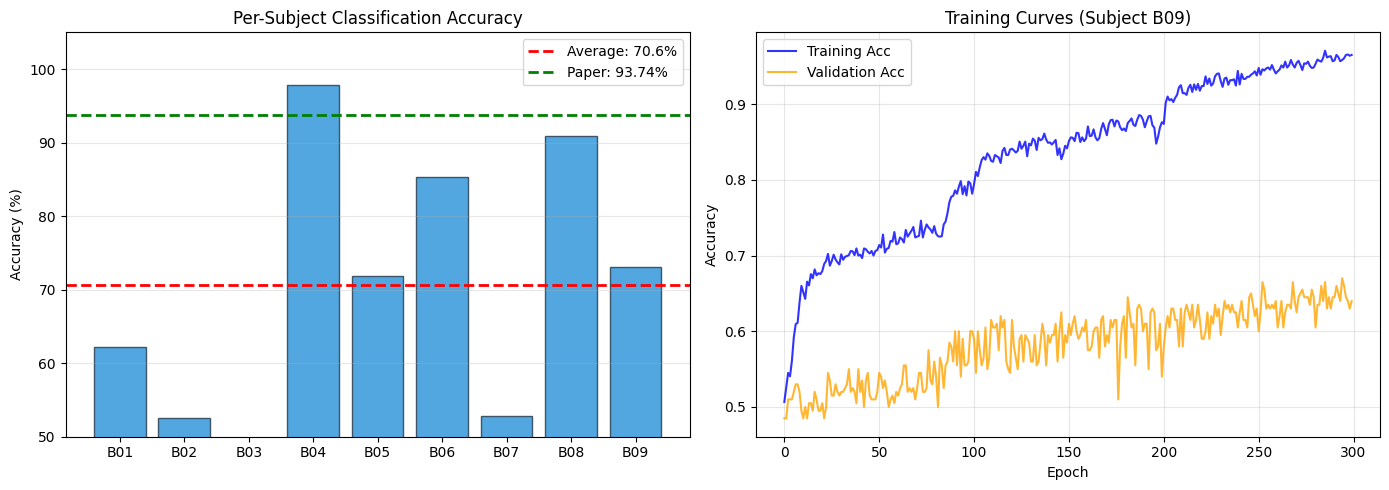


Done! Results have been computed for all subjects.


In [22]:
# %% =========================================================================
# CELL 12: FINAL RESULTS SUMMARY
# =============================================================================
import matplotlib.pyplot as plt

if len(all_results) > 0:
    print("\n" + "═" * 60)
    print("  FINAL RESULTS — MS-CNN on BCI Competition IV-2b")
    print("═" * 60)
    print(f"  {'Subject':<10} {'Accuracy':>10} {'Kappa':>10} {'F1':>10}")
    print("  " + "─" * 40)

    accuracies = []
    kappas = []
    f1s = []

    for sid, res in sorted(all_results.items()):
        print(f"  B{sid:02d}       {res['accuracy']:>9.2f}% {res['kappa']:>9.4f} {res['f1']:>9.4f}")
        accuracies.append(res['accuracy'])
        kappas.append(res['kappa'])
        f1s.append(res['f1'])

    print("  " + "─" * 40)
    print(f"  {'AVERAGE':<10} {np.mean(accuracies):>9.2f}% {np.mean(kappas):>9.4f} {np.mean(f1s):>9.4f}")
    print(f"  {'STD':<10} {np.std(accuracies):>9.2f}% {np.std(kappas):>9.4f} {np.std(f1s):>9.4f}")
    print("═" * 60)
    print(f"  Paper target:  93.74%")
    print(f"  Your result:   {np.mean(accuracies):.2f}%")
    print("═" * 60)

    # --- Bar Chart: Per-Subject Accuracy ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    subjects = [f'B{s:02d}' for s in sorted(all_results.keys())]

    axes[0].bar(subjects, accuracies, color='#3498db', edgecolor='#2c3e50', alpha=0.85)
    axes[0].axhline(y=np.mean(accuracies), color='red', linestyle='--',
                    linewidth=2, label=f'Average: {np.mean(accuracies):.1f}%')
    axes[0].axhline(y=93.74, color='green', linestyle='--',
                    linewidth=2, label='Paper: 93.74%')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Per-Subject Classification Accuracy')
    axes[0].legend()
    axes[0].set_ylim([50, 105])
    axes[0].grid(axis='y', alpha=0.3)

    # --- Line Plot: Training Curves (last subject) ---
    last_sid = max(all_results.keys())
    last_hist = all_results[last_sid]['history']

    axes[1].plot(last_hist['accuracy'], label='Training Acc', color='blue', alpha=0.8)
    if 'val_accuracy' in last_hist:
        axes[1].plot(last_hist['val_accuracy'], label='Validation Acc',
                     color='orange', alpha=0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Training Curves (Subject B{last_sid:02d})')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Save results ---
    print("\nDone! Results have been computed for all subjects.")

else:
    print("\n[ERROR] No subjects were successfully processed.")
    print("Please check that all .gdf files are in the DATA_DIR directory.")
    print(f"Expected directory: {DATA_DIR}")
    print("Expected files: B0101T.gdf, B0102T.gdf, ..., B0905E.gdf")